# 04 — Baseline Models with Cross-Validation
**Aviation Safety Risk Prediction — NTSB + NOAA Dataset**

Trains six classifiers (Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost, MLP),
compares them with 5-fold stratified cross-validation and on the validation set, then evaluates
the best one on the held-out test set and saves it.

### Priority metric
`FATL recall` — missing a fatal accident is far worse than a false alarm in a safety system.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, time, warnings, re
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score)
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED       = 42
OUTPUT_DIR = 'outputs'
MODEL_DIR  = 'baseline_models'
os.makedirs(MODEL_DIR, exist_ok=True)

LABEL_MAP   = {0:'NONE',1:'MINR',2:'SERS',3:'FATL'}
LABEL_NAMES = ['NONE','MINR','SERS','FATL']
CLASS_ORDER = [0,1,2,3]
N_CV_FOLDS  = 5


## 1. Load Data

In [11]:
X_train_raw = pd.read_csv(f'{OUTPUT_DIR}/X_train.csv')
X_val_raw   = pd.read_csv(f'{OUTPUT_DIR}/X_val.csv')
X_test_raw  = pd.read_csv(f'{OUTPUT_DIR}/X_test.csv')

y_train = pd.read_csv(f'{OUTPUT_DIR}/y_train.csv').squeeze()
y_val   = pd.read_csv(f'{OUTPUT_DIR}/y_val.csv').squeeze()
y_test  = pd.read_csv(f'{OUTPUT_DIR}/y_test.csv').squeeze()

class_weights = joblib.load(f'{OUTPUT_DIR}/class_weights.pkl')
sample_weights_train = compute_sample_weight(class_weight=class_weights, y=y_train)

print(f'X_train: {X_train_raw.shape}')
print(f'X_val  : {X_val_raw.shape}')
print(f'X_test : {X_test_raw.shape}')
print(f'y_train dist: {dict(y_train.value_counts().sort_index().rename(LABEL_MAP))}')


X_train: (17286, 515)
X_val  : (5762, 515)
X_test : (5762, 515)
y_train dist: {'NONE': 9645, 'MINR': 2524, 'SERS': 2231, 'FATL': 2886}


In [12]:
# ── LightGBM column sanitization ──────────────────────────────────────────
# LightGBM rejects brackets/special characters in column names, so sanitized
# copies of the feature matrices are built for it.

def sanitize_lgb_columns(df):
    """Replace any character that LightGBM rejects with underscore, then
    deduplicate column names that become identical after sanitization."""
    df = df.copy()
    new_cols = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    seen = {}
    deduped = []
    for col in new_cols:
        if col in seen:
            seen[col] += 1
            deduped.append(f'{col}_{seen[col]}')
        else:
            seen[col] = 0
            deduped.append(col)
    df.columns = deduped
    return df

X_train_lgb = sanitize_lgb_columns(X_train_raw)
X_val_lgb   = sanitize_lgb_columns(X_val_raw)
X_test_lgb  = sanitize_lgb_columns(X_test_raw)

# NumPy arrays for all other models
X_train = X_train_raw.values
X_val   = X_val_raw.values
X_test  = X_test_raw.values

print(f'LGB sanitized X_train: {X_train_lgb.shape}')
print('Column sanitization done ✓ — using X_train_lgb / X_train variants throughout')


LGB sanitized X_train: (17286, 515)
Column sanitization done ✓ — using X_train_lgb / X_train variants throughout


## 2. Helper Functions

In [13]:
def evaluate_model(model, X, y_true, split_name='val', model_name='', is_lgb=False):
    """Evaluate on a single split. Returns metrics dict."""
    X_eval = X  # sanitized DataFrame for LightGBM, NumPy array otherwise
    y_pred = model.predict(X_eval)

    try:
        y_prob = model.predict_proba(X_eval)
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc = np.nan

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc      = accuracy_score(y_true, y_pred)
    report   = classification_report(y_true, y_pred, output_dict=True,
                                     target_names=LABEL_NAMES, zero_division=0)
    fatl_f1  = report.get('FATL', {}).get('f1-score', np.nan)
    fatl_rec = report.get('FATL', {}).get('recall',   np.nan)

    print(f'\n{"="*55}')
    print(f'  {model_name} — {split_name.upper()} SET')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))
    print(f'  Macro F1  : {macro_f1:.4f}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  AUC (OvR) : {auc:.4f}')
    print(f'  FATL F1   : {fatl_f1:.4f}  ← priority metric')
    print(f'  FATL Rec  : {fatl_rec:.4f}  ← how many fatals we catch')

    return dict(model=model_name, split=split_name, macro_f1=macro_f1,
                accuracy=acc, auc=auc, fatl_f1=fatl_f1, fatl_recall=fatl_rec)


def plot_confusion_matrix(model, X, y_true, model_name, split_name='val'):
    y_pred = model.predict(X)
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER, normalize='true')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} — Confusion Matrix ({split_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/cm_{model_name.replace(" ","_").lower()}_{split_name}.png', dpi=150)
    plt.show()

print('Helper functions defined ✓')


Helper functions defined ✓


## 3. Cross-Validation Scoring
We run 5-fold stratified CV **before** final training to:
- Compare models on stable, seed-independent metrics
- Compute mean ± std for each metric
- Use FATL recall as the primary ranking criterion

> **Note**: CV here uses `X_train` only (60% of data).  
> The val set (20%) is held out for final threshold tuning and the test set (20%) for final evaluation.


In [14]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

cv_skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)

# We define a FATL-recall scorer and macro-F1 scorer
from sklearn.metrics import make_scorer, recall_score

def fatl_recall_scorer(y_true, y_pred):
    """Recall for class 3 (FATL)."""
    return recall_score(y_true, y_pred, labels=[3], average='macro', zero_division=0)

scoring = {
    'macro_f1':    make_scorer(f1_score, average='macro', zero_division=0),
    'fatl_recall': make_scorer(fatl_recall_scorer),
    'accuracy':    'accuracy',
}


In [15]:
# Define model blueprints for CV (not yet fitted)
cat_class_weights_list = [class_weights[i] for i in CLASS_ORDER]

model_blueprints = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight=class_weights,
        solver='lbfgs', random_state=SEED, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', class_weight=class_weights,
        random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        objective='multi:softprob', num_class=4, eval_metric='mlogloss',
        use_label_encoder=False, random_state=SEED, n_jobs=-1, verbosity=0),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05, l2_leaf_reg=3,
        class_weights=[float(class_weights[i]) for i in CLASS_ORDER],  # weights ordered by class index
        loss_function='MultiClass', random_seed=SEED, verbose=0),
}
# LightGBM (sanitized columns) and MLP (sample_weight) are cross-validated separately below

cv_results = {}

for name, blueprint in model_blueprints.items():
    print(f'CV — {name}...')
    t0 = time.time()
    scores = {'macro_f1': [], 'fatl_recall': [], 'accuracy': []}

    for fold, (tr_idx, val_idx) in enumerate(cv_skf.split(X_train, y_train)):
        Xtr, ytr = X_train[tr_idx], y_train.iloc[tr_idx]
        Xvl, yvl = X_train[val_idx], y_train.iloc[val_idx]
        sw_tr = sample_weights_train[tr_idx]

        # CatBoost doesn't support clone() — reinstantiate directly
        if name == 'CatBoost':
            m = CatBoostClassifier(
                iterations=300, depth=6, learning_rate=0.05, l2_leaf_reg=3,
                class_weights=[float(class_weights[i]) for i in CLASS_ORDER],
                loss_function='MultiClass', random_seed=SEED, verbose=0)
        else:
            m = clone(blueprint)

        if name == 'XGBoost':
            m.fit(Xtr, ytr, sample_weight=sw_tr)
        else:
            m.fit(Xtr, ytr)

        ypred = m.predict(Xvl)
        scores['macro_f1'].append(f1_score(yvl, ypred, average='macro', zero_division=0))
        scores['fatl_recall'].append(fatl_recall_scorer(yvl, ypred))
        scores['accuracy'].append(accuracy_score(yvl, ypred))

    elapsed = time.time() - t0
    cv_results[name] = {
        'macro_f1_mean':    np.mean(scores['macro_f1']),
        'macro_f1_std':     np.std(scores['macro_f1']),
        'fatl_recall_mean': np.mean(scores['fatl_recall']),
        'fatl_recall_std':  np.std(scores['fatl_recall']),
        'accuracy_mean':    np.mean(scores['accuracy']),
        'accuracy_std':     np.std(scores['accuracy']),
    }
    print(f'  macro_f1={cv_results[name]["macro_f1_mean"]:.4f}±{cv_results[name]["macro_f1_std"]:.4f}'
          f'  fatl_recall={cv_results[name]["fatl_recall_mean"]:.4f}±{cv_results[name]["fatl_recall_std"]:.4f}'
          f'  ({elapsed:.0f}s)')

CV — Logistic Regression...


  macro_f1=0.5560±0.0070  fatl_recall=0.8482±0.0147  (59s)
CV — Random Forest...
  macro_f1=0.6214±0.0102  fatl_recall=0.8479±0.0122  (72s)
CV — XGBoost...
  macro_f1=0.6262±0.0071  fatl_recall=0.8604±0.0084  (107s)
CV — CatBoost...
  macro_f1=0.5862±0.0086  fatl_recall=0.8399±0.0104  (149s)


In [16]:
# Manual CV for LightGBM (sanitized columns)
print('CV — LightGBM (manual)...')
t0 = time.time()
lgb_cv_scores = {'macro_f1': [], 'fatl_recall': [], 'accuracy': []}

for fold, (tr_idx, val_idx) in enumerate(cv_skf.split(X_train_lgb, y_train)):
    Xtr = X_train_lgb.iloc[tr_idx]; ytr = y_train.iloc[tr_idx]
    Xvl = X_train_lgb.iloc[val_idx]; yvl = y_train.iloc[val_idx]
    sw_tr = sample_weights_train[tr_idx]

    m = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, class_weight=class_weights,
        objective='multiclass', num_class=4, metric='multi_logloss',
        random_state=SEED, n_jobs=-1, verbose=-1)
    m.fit(Xtr, ytr, sample_weight=sw_tr,
          eval_set=[(Xvl, yvl)],
          callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(period=-1)])
    ypred = m.predict(Xvl)
    lgb_cv_scores['macro_f1'].append(f1_score(yvl, ypred, average='macro', zero_division=0))
    lgb_cv_scores['fatl_recall'].append(fatl_recall_scorer(yvl, ypred))
    lgb_cv_scores['accuracy'].append(accuracy_score(yvl, ypred))
    print(f'  fold {fold+1}: macro_f1={lgb_cv_scores["macro_f1"][-1]:.4f}  fatl_recall={lgb_cv_scores["fatl_recall"][-1]:.4f}')

cv_results['LightGBM'] = {
    'macro_f1_mean':    np.mean(lgb_cv_scores['macro_f1']),
    'macro_f1_std':     np.std(lgb_cv_scores['macro_f1']),
    'fatl_recall_mean': np.mean(lgb_cv_scores['fatl_recall']),
    'fatl_recall_std':  np.std(lgb_cv_scores['fatl_recall']),
    'accuracy_mean':    np.mean(lgb_cv_scores['accuracy']),
    'accuracy_std':     np.std(lgb_cv_scores['accuracy']),
}
print(f'LightGBM CV: macro_f1={cv_results["LightGBM"]["macro_f1_mean"]:.4f}  '
      f'fatl_recall={cv_results["LightGBM"]["fatl_recall_mean"]:.4f}  ({time.time()-t0:.0f}s)')


CV — LightGBM (manual)...
  fold 1: macro_f1=0.5458  fatl_recall=0.8475
  fold 2: macro_f1=0.5445  fatl_recall=0.8720
  fold 3: macro_f1=0.5475  fatl_recall=0.8579
  fold 4: macro_f1=0.5456  fatl_recall=0.8735
  fold 5: macro_f1=0.5381  fatl_recall=0.8614
LightGBM CV: macro_f1=0.5443  fatl_recall=0.8624  (76s)


In [17]:
# Manual CV for MLP (sample_weight in fit, no internal val fraction)
print('CV — MLP (manual)...')
t0 = time.time()
mlp_cv_scores = {'macro_f1': [], 'fatl_recall': [], 'accuracy': []}

for fold, (tr_idx, val_idx) in enumerate(cv_skf.split(X_train, y_train)):
    Xtr = X_train[tr_idx]; ytr = y_train.iloc[tr_idx]
    Xvl = X_train[val_idx]; yvl = y_train.iloc[val_idx]
    sw_tr = sample_weights_train[tr_idx]

    m = MLPClassifier(
        hidden_layer_sizes=(256,128,64), activation='relu', solver='adam',
        alpha=0.001, batch_size=256, learning_rate='adaptive',
        learning_rate_init=0.001, max_iter=200,
        # Trained on the full fold, like the other models
        early_stopping=False,
        random_state=SEED, verbose=False)
    m.fit(Xtr, ytr, sample_weight=sw_tr)
    ypred = m.predict(Xvl)
    mlp_cv_scores['macro_f1'].append(f1_score(yvl, ypred, average='macro', zero_division=0))
    mlp_cv_scores['fatl_recall'].append(fatl_recall_scorer(yvl, ypred))
    mlp_cv_scores['accuracy'].append(accuracy_score(yvl, ypred))
    print(f'  fold {fold+1}: macro_f1={mlp_cv_scores["macro_f1"][-1]:.4f}  fatl_recall={mlp_cv_scores["fatl_recall"][-1]:.4f}')

cv_results['MLP'] = {
    'macro_f1_mean':    np.mean(mlp_cv_scores['macro_f1']),
    'macro_f1_std':     np.std(mlp_cv_scores['macro_f1']),
    'fatl_recall_mean': np.mean(mlp_cv_scores['fatl_recall']),
    'fatl_recall_std':  np.std(mlp_cv_scores['fatl_recall']),
    'accuracy_mean':    np.mean(mlp_cv_scores['accuracy']),
    'accuracy_std':     np.std(mlp_cv_scores['accuracy']),
}
print(f'MLP CV: macro_f1={cv_results["MLP"]["macro_f1_mean"]:.4f}  '
      f'fatl_recall={cv_results["MLP"]["fatl_recall_mean"]:.4f}  ({time.time()-t0:.0f}s)')


CV — MLP (manual)...
  fold 1: macro_f1=0.5851  fatl_recall=0.8371
  fold 2: macro_f1=0.5696  fatl_recall=0.8426
  fold 3: macro_f1=0.5771  fatl_recall=0.8302
  fold 4: macro_f1=0.5717  fatl_recall=0.8492
  fold 5: macro_f1=0.5850  fatl_recall=0.8215
MLP CV: macro_f1=0.5777  fatl_recall=0.8361  (684s)



  CROSS-VALIDATION RESULTS (5-fold stratified)
              model  macro_f1_mean  macro_f1_std  fatl_recall_mean  fatl_recall_std  accuracy_mean  accuracy_std
           LightGBM         0.5443        0.0032            0.8624           0.0096         0.5146        0.0049
            XGBoost         0.6262        0.0071            0.8604           0.0084         0.6733        0.0063
Logistic Regression         0.5560        0.0070            0.8482           0.0147         0.5888        0.0086
      Random Forest         0.6214        0.0102            0.8479           0.0122         0.7559        0.0047
           CatBoost         0.5862        0.0086            0.8399           0.0104         0.6152        0.0083
                MLP         0.5777        0.0065            0.8361           0.0096         0.6716        0.0126


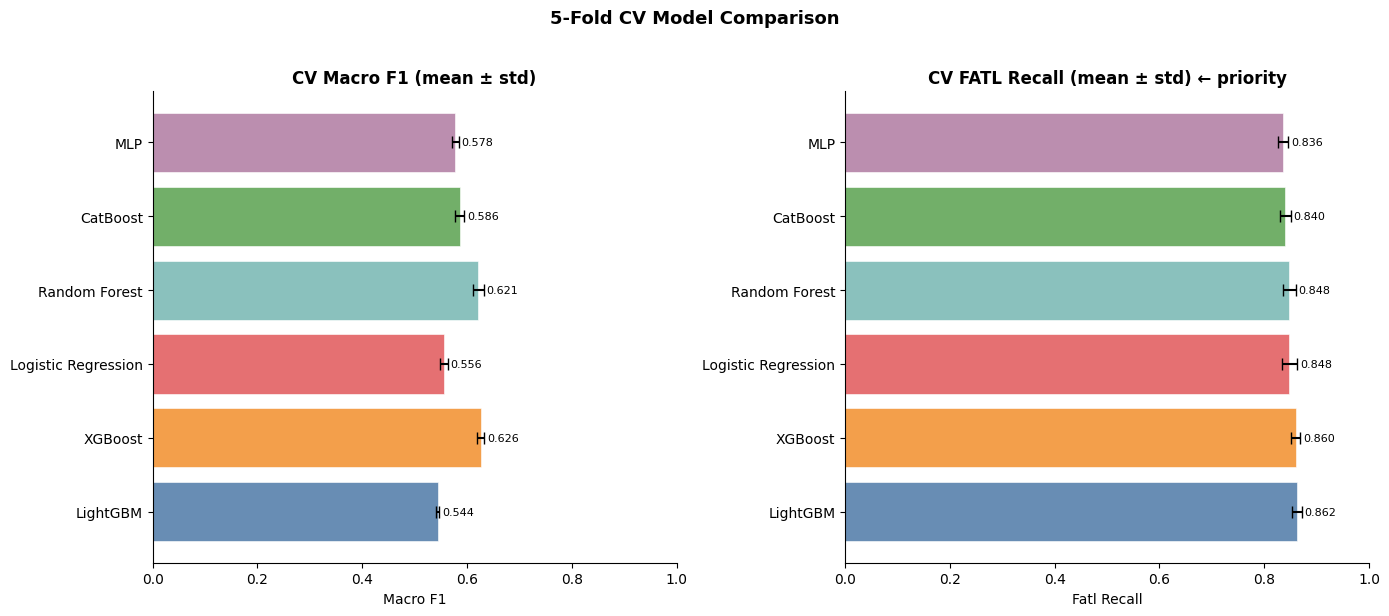

In [18]:
# CV Results table
cv_df = pd.DataFrame(cv_results).T.reset_index().rename(columns={'index':'model'})
cv_df = cv_df.sort_values('fatl_recall_mean', ascending=False).reset_index(drop=True)
cv_df = cv_df.round(4)
print('\n' + '='*70)
print('  CROSS-VALIDATION RESULTS (5-fold stratified)')
print('='*70)
print(cv_df.to_string(index=False))
cv_df.to_csv(f'{MODEL_DIR}/cv_results.csv', index=False)

# Plot: CV macro F1 and FATL recall with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors6 = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#b07aa1']

for ax, metric, title in zip(axes,
    ['macro_f1', 'fatl_recall'],
    ['CV Macro F1 (mean ± std)', 'CV FATL Recall (mean ± std) ← priority']):
    means = cv_df[f'{metric}_mean'].values
    stds  = cv_df[f'{metric}_std'].values
    labels= cv_df['model'].values
    y_pos = range(len(labels))
    ax.barh(y_pos, means, xerr=stds, color=colors6[:len(labels)],
            edgecolor='white', linewidth=0.5, capsize=4, alpha=0.85)
    ax.set_yticks(y_pos); ax.set_yticklabels(labels)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric.replace('_',' ').title())
    ax.set_xlim(0, 1)
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(m + s + 0.005, i, f'{m:.3f}', va='center', fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('5-Fold CV Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Train Final Models on Full Training Set

Training Logistic Regression on full train set...
Done in 20.2s

  Logistic Regression — VAL SET
              precision    recall  f1-score   support

        NONE       0.81      0.60      0.69      3215
        MINR       0.28      0.45      0.34       841
        SERS       0.32      0.43      0.37       744
        FATL       0.84      0.87      0.85       962

    accuracy                           0.60      5762
   macro avg       0.56      0.59      0.56      5762
weighted avg       0.67      0.60      0.63      5762

  Macro F1  : 0.5639
  Accuracy  : 0.6033
  AUC (OvR) : 0.8132
  FATL F1   : 0.8523  ← priority metric
  FATL Rec  : 0.8669  ← how many fatals we catch


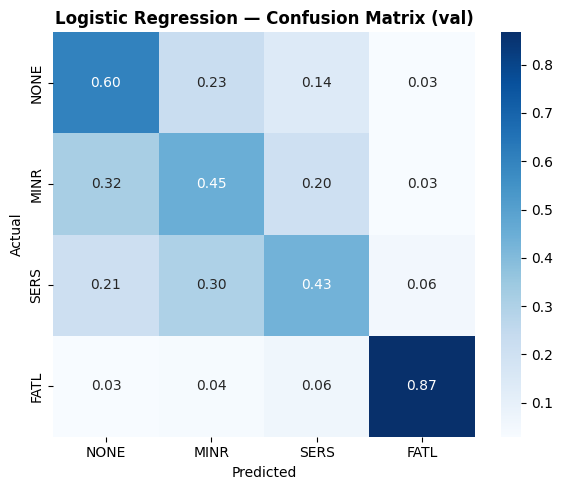

['baseline_models/logistic_regression.pkl']

In [19]:
print('Training Logistic Regression on full train set...')
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight=class_weights,
                        solver='lbfgs', random_state=SEED, n_jobs=-1)
lr.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')
metrics_lr_val = evaluate_model(lr, X_val, y_val, 'val', 'Logistic Regression')
plot_confusion_matrix(lr, X_val, y_val, 'Logistic Regression')
joblib.dump(lr, f'{MODEL_DIR}/logistic_regression.pkl')


Training Random Forest...
Done in 15.9s

  Random Forest — VAL SET
              precision    recall  f1-score   support

        NONE       0.73      0.98      0.83      3215
        MINR       0.91      0.22      0.35       841
        SERS       0.84      0.38      0.52       744
        FATL       0.91      0.86      0.89       962

    accuracy                           0.77      5762
   macro avg       0.85      0.61      0.65      5762
weighted avg       0.80      0.77      0.73      5762

  Macro F1  : 0.6503
  Accuracy  : 0.7707
  AUC (OvR) : 0.8787
  FATL F1   : 0.8875  ← priority metric
  FATL Rec  : 0.8649  ← how many fatals we catch


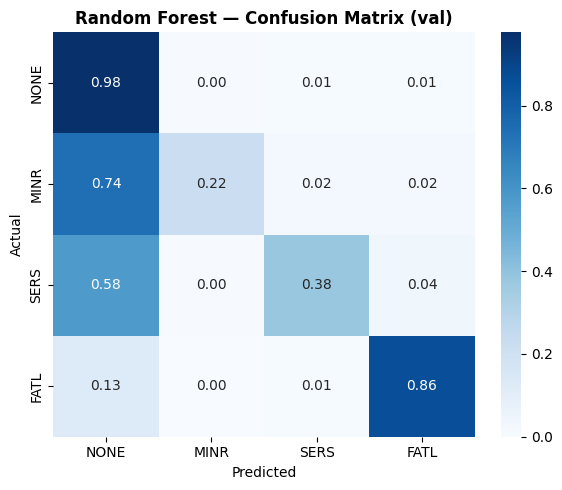

['baseline_models/random_forest.pkl']

In [20]:
print('Training Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2,
                             max_features='sqrt', class_weight=class_weights,
                             random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')
metrics_rf_val = evaluate_model(rf, X_val, y_val, 'val', 'Random Forest')
plot_confusion_matrix(rf, X_val, y_val, 'Random Forest')
joblib.dump(rf, f'{MODEL_DIR}/random_forest.pkl')


Training XGBoost...
Done in 42.1s  |  Best iter: 499

  XGBoost — VAL SET
              precision    recall  f1-score   support

        NONE       0.82      0.77      0.80      3215
        MINR       0.39      0.49      0.44       841
        SERS       0.49      0.51      0.50       744
        FATL       0.91      0.88      0.89       962

    accuracy                           0.71      5762
   macro avg       0.65      0.66      0.66      5762
weighted avg       0.73      0.71      0.72      5762

  Macro F1  : 0.6553
  Accuracy  : 0.7123
  AUC (OvR) : 0.8729
  FATL F1   : 0.8934  ← priority metric
  FATL Rec  : 0.8753  ← how many fatals we catch


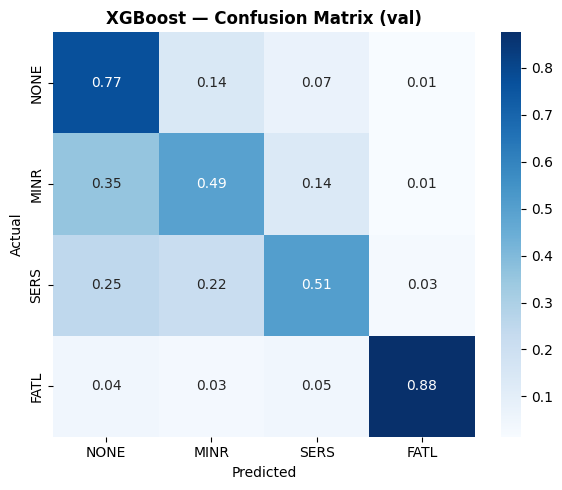

['baseline_models/xgboost.pkl']

In [21]:
print('Training XGBoost...')
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    objective='multi:softprob', num_class=4, eval_metric='mlogloss',
    use_label_encoder=False, random_state=SEED, n_jobs=-1, verbosity=0,
    early_stopping_rounds=30,
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train,
              eval_set=[(X_val, y_val)], verbose=False)
print(f'Done in {time.time()-t0:.1f}s  |  Best iter: {xgb_model.best_iteration}')
metrics_xgb_val = evaluate_model(xgb_model, X_val, y_val, 'val', 'XGBoost')
plot_confusion_matrix(xgb_model, X_val, y_val, 'XGBoost')
joblib.dump(xgb_model, f'{MODEL_DIR}/xgboost.pkl')


Training LightGBM...
Done in 25.5s  |  Best iter: 500

  LightGBM — VAL SET
              precision    recall  f1-score   support

        NONE       0.82      0.76      0.79      3215
        MINR       0.36      0.47      0.41       841
        SERS       0.48      0.51      0.50       744
        FATL       0.91      0.88      0.90       962

    accuracy                           0.71      5762
   macro avg       0.65      0.65      0.65      5762
weighted avg       0.73      0.71      0.71      5762

  Macro F1  : 0.6479
  Accuracy  : 0.7051
  AUC (OvR) : 0.8684
  FATL F1   : 0.8955  ← priority metric
  FATL Rec  : 0.8773  ← how many fatals we catch


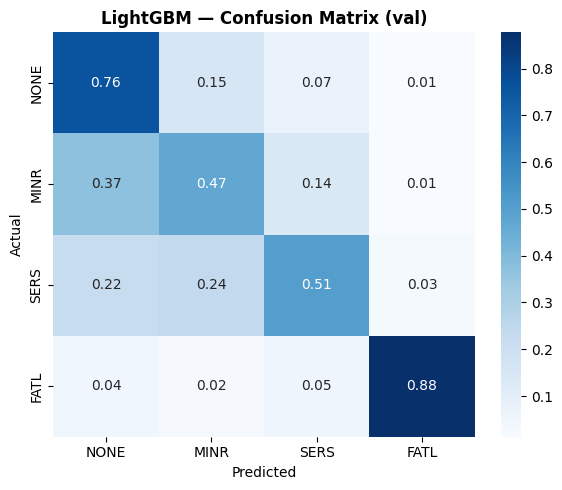

['baseline_models/lightgbm.pkl']

In [22]:
print('Training LightGBM...')
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_alpha=0.1, reg_lambda=1.0, class_weight=class_weights,
    objective='multiclass', num_class=4, metric='multi_logloss',
    random_state=SEED, n_jobs=-1, verbose=-1)
lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)])
print(f'Done in {time.time()-t0:.1f}s  |  Best iter: {lgb_model.best_iteration_}')
metrics_lgb_val = evaluate_model(lgb_model, X_val_lgb, y_val, 'val', 'LightGBM')
plot_confusion_matrix(lgb_model, X_val_lgb, y_val, 'LightGBM')
joblib.dump(lgb_model, f'{MODEL_DIR}/lightgbm.pkl')


Training CatBoost...
Done in 54.2s  |  Best iter: 498

  CatBoost — VAL SET
              precision    recall  f1-score   support

        NONE       0.82      0.64      0.72      3215
        MINR       0.30      0.51      0.38       841
        SERS       0.39      0.47      0.43       744
        FATL       0.89      0.87      0.88       962

    accuracy                           0.64      5762
   macro avg       0.60      0.62      0.60      5762
weighted avg       0.70      0.64      0.66      5762

  Macro F1  : 0.6015
  Accuracy  : 0.6369
  AUC (OvR) : 0.8403
  FATL F1   : 0.8814  ← priority metric
  FATL Rec  : 0.8690  ← how many fatals we catch


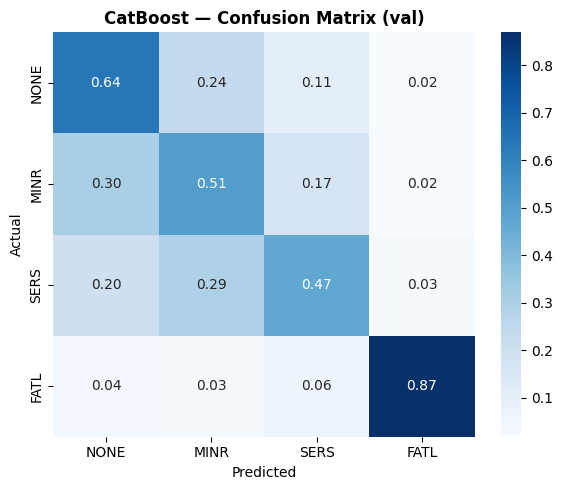

['baseline_models/catboost.pkl']

In [23]:
print('Training CatBoost...')
t0 = time.time()
cat_class_weights_list = [class_weights[i] for i in CLASS_ORDER]
cat_model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=3,
    class_weights=cat_class_weights_list,
    loss_function='MultiClass', eval_metric='MultiClass',
    random_seed=SEED, early_stopping_rounds=30, verbose=0)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
print(f'Done in {time.time()-t0:.1f}s  |  Best iter: {cat_model.best_iteration_}')
metrics_cat_val = evaluate_model(cat_model, X_val, y_val, 'val', 'CatBoost')
plot_confusion_matrix(cat_model, X_val, y_val, 'CatBoost')
joblib.dump(cat_model, f'{MODEL_DIR}/catboost.pkl')


Training MLP on FULL X_train (no internal validation fraction)...
Done in 207.0s  |  Iterations: 59

  MLP — VAL SET
              precision    recall  f1-score   support

        NONE       0.75      0.81      0.78      3215
        MINR       0.36      0.31      0.34       841
        SERS       0.50      0.40      0.45       744
        FATL       0.87      0.86      0.86       962

    accuracy                           0.70      5762
   macro avg       0.62      0.60      0.61      5762
weighted avg       0.68      0.70      0.69      5762

  Macro F1  : 0.6066
  Accuracy  : 0.6952
  AUC (OvR) : 0.8208
  FATL F1   : 0.8640  ← priority metric
  FATL Rec  : 0.8617  ← how many fatals we catch


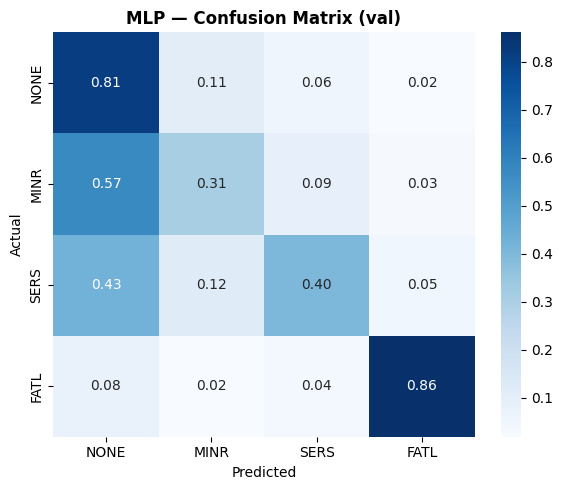

['baseline_models/mlp.pkl']

In [24]:
print('Training MLP on FULL X_train (no internal validation fraction)...')
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(256,128,64), activation='relu', solver='adam',
    alpha=0.001, batch_size=256, learning_rate='adaptive',
    learning_rate_init=0.001, max_iter=300,
    # Trains on the full X_train like the other models (no early stopping);
    # stops when the training loss has not improved for 20 iterations
    early_stopping=False, n_iter_no_change=20,
    random_state=SEED, verbose=False)
mlp.fit(X_train, y_train, sample_weight=sample_weights_train)
print(f'Done in {time.time()-t0:.1f}s  |  Iterations: {mlp.n_iter_}')
metrics_mlp_val = evaluate_model(mlp, X_val, y_val, 'val', 'MLP')
plot_confusion_matrix(mlp, X_val, y_val, 'MLP')
joblib.dump(mlp, f'{MODEL_DIR}/mlp.pkl')


## 5. Validation Set Comparison

In [25]:
all_metrics = [metrics_lr_val, metrics_rf_val, metrics_xgb_val,
               metrics_lgb_val, metrics_cat_val, metrics_mlp_val]

results_df = pd.DataFrame(all_metrics).drop(columns=['split'])
results_df = results_df.sort_values('fatl_recall', ascending=False).reset_index(drop=True)
results_df[['macro_f1','accuracy','auc','fatl_f1','fatl_recall']] =     results_df[['macro_f1','accuracy','auc','fatl_f1','fatl_recall']].round(4)

print('\n' + '='*65)
print('  MODEL COMPARISON — VALIDATION SET (sorted by FATL recall)')
print('='*65)
print(results_df.to_string(index=False))
results_df.to_csv(f'{MODEL_DIR}/val_comparison.csv', index=False)



  MODEL COMPARISON — VALIDATION SET (sorted by FATL recall)
              model  macro_f1  accuracy    auc  fatl_f1  fatl_recall
           LightGBM    0.6479    0.7051 0.8684   0.8955       0.8773
            XGBoost    0.6553    0.7123 0.8729   0.8934       0.8753
           CatBoost    0.6015    0.6369 0.8403   0.8814       0.8690
Logistic Regression    0.5639    0.6033 0.8132   0.8523       0.8669
      Random Forest    0.6503    0.7707 0.8787   0.8875       0.8649
                MLP    0.6066    0.6952 0.8208   0.8640       0.8617


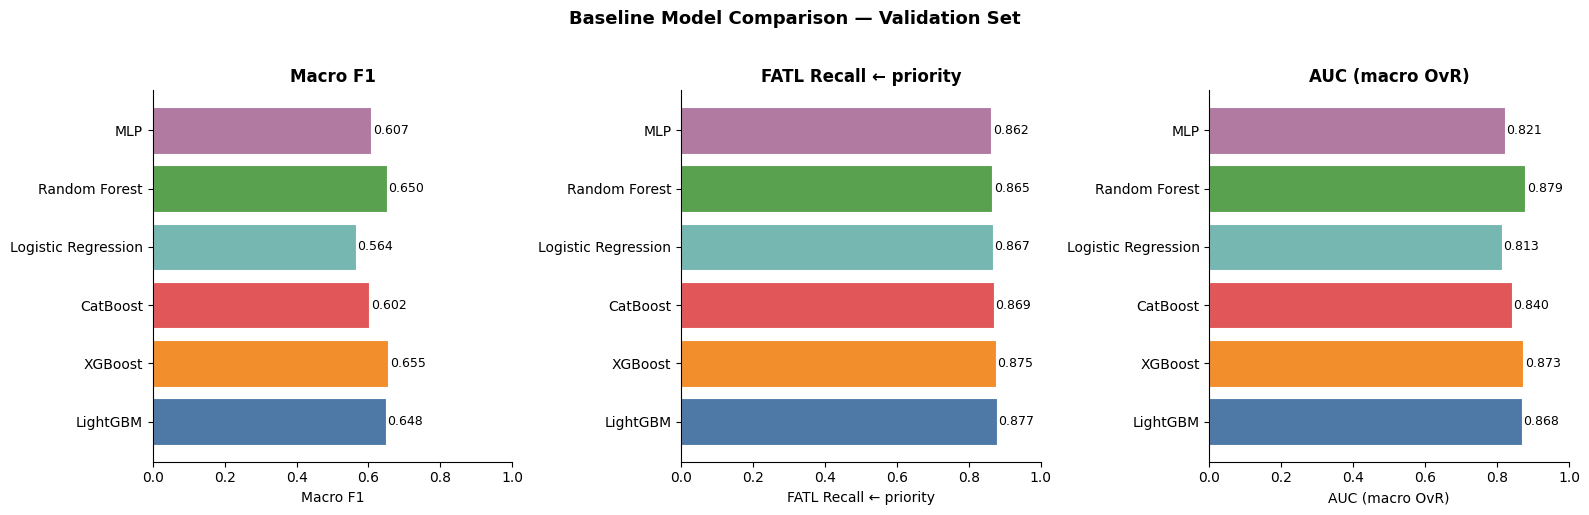

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['macro_f1', 'fatl_recall', 'auc']
titles = ['Macro F1', 'FATL Recall ← priority', 'AUC (macro OvR)']
colors6 = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#b07aa1']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    bars = ax.barh(results_df['model'], results_df[metric],
                   color=colors6[:len(results_df)], edgecolor='white', linewidth=0.8)
    ax.set_xlabel(title); ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Baseline Model Comparison — Validation Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Final Evaluation on Held-Out Test Set

Best model (by FATL recall on val): LightGBM
Evaluating on HELD-OUT TEST SET...


  LightGBM — TEST SET
              precision    recall  f1-score   support

        NONE       0.81      0.76      0.78      3215
        MINR       0.35      0.43      0.39       841
        SERS       0.49      0.52      0.51       744
        FATL       0.91      0.89      0.90       962

    accuracy                           0.70      5762
   macro avg       0.64      0.65      0.64      5762
weighted avg       0.72      0.70      0.71      5762

  Macro F1  : 0.6436
  Accuracy  : 0.7001
  AUC (OvR) : 0.8640
  FATL F1   : 0.9004  ← priority metric
  FATL Rec  : 0.8877  ← how many fatals we catch


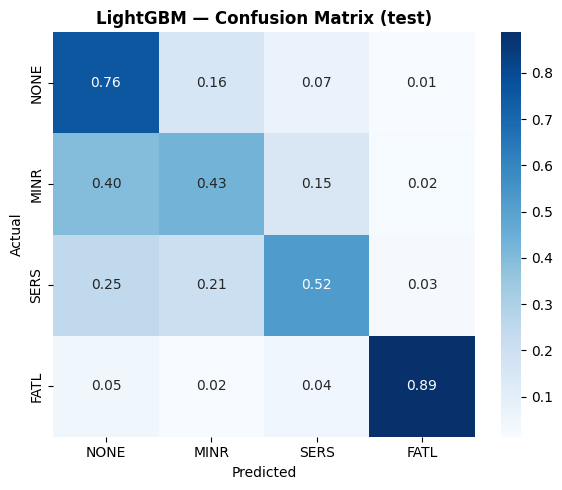


Best model saved to baseline_models/best_model.pkl
→ Will be wrapped with conformal prediction in 05_uncertainty.ipynb


In [27]:
best_model_name = results_df.iloc[0]['model']
model_map = {
    'Logistic Regression': lr,
    'Random Forest':        rf,
    'XGBoost':              xgb_model,
    'LightGBM':             lgb_model,
    'CatBoost':             cat_model,
    'MLP':                  mlp,
}
best_model = model_map[best_model_name]

# Sanitized X_test for LightGBM, standard array otherwise
X_test_for_best = X_test_lgb if best_model_name == 'LightGBM' else X_test

print(f'Best model (by FATL recall on val): {best_model_name}')
print('Evaluating on HELD-OUT TEST SET...\n')
metrics_test = evaluate_model(best_model, X_test_for_best, y_test, 'test', best_model_name)
plot_confusion_matrix(best_model, X_test_for_best, y_test, best_model_name, split_name='test')

joblib.dump(best_model, f'{MODEL_DIR}/best_model.pkl')
print(f'\nBest model saved to {MODEL_DIR}/best_model.pkl')
print('→ Will be wrapped with conformal prediction in 05_uncertainty.ipynb')


## 7. Feature Importance

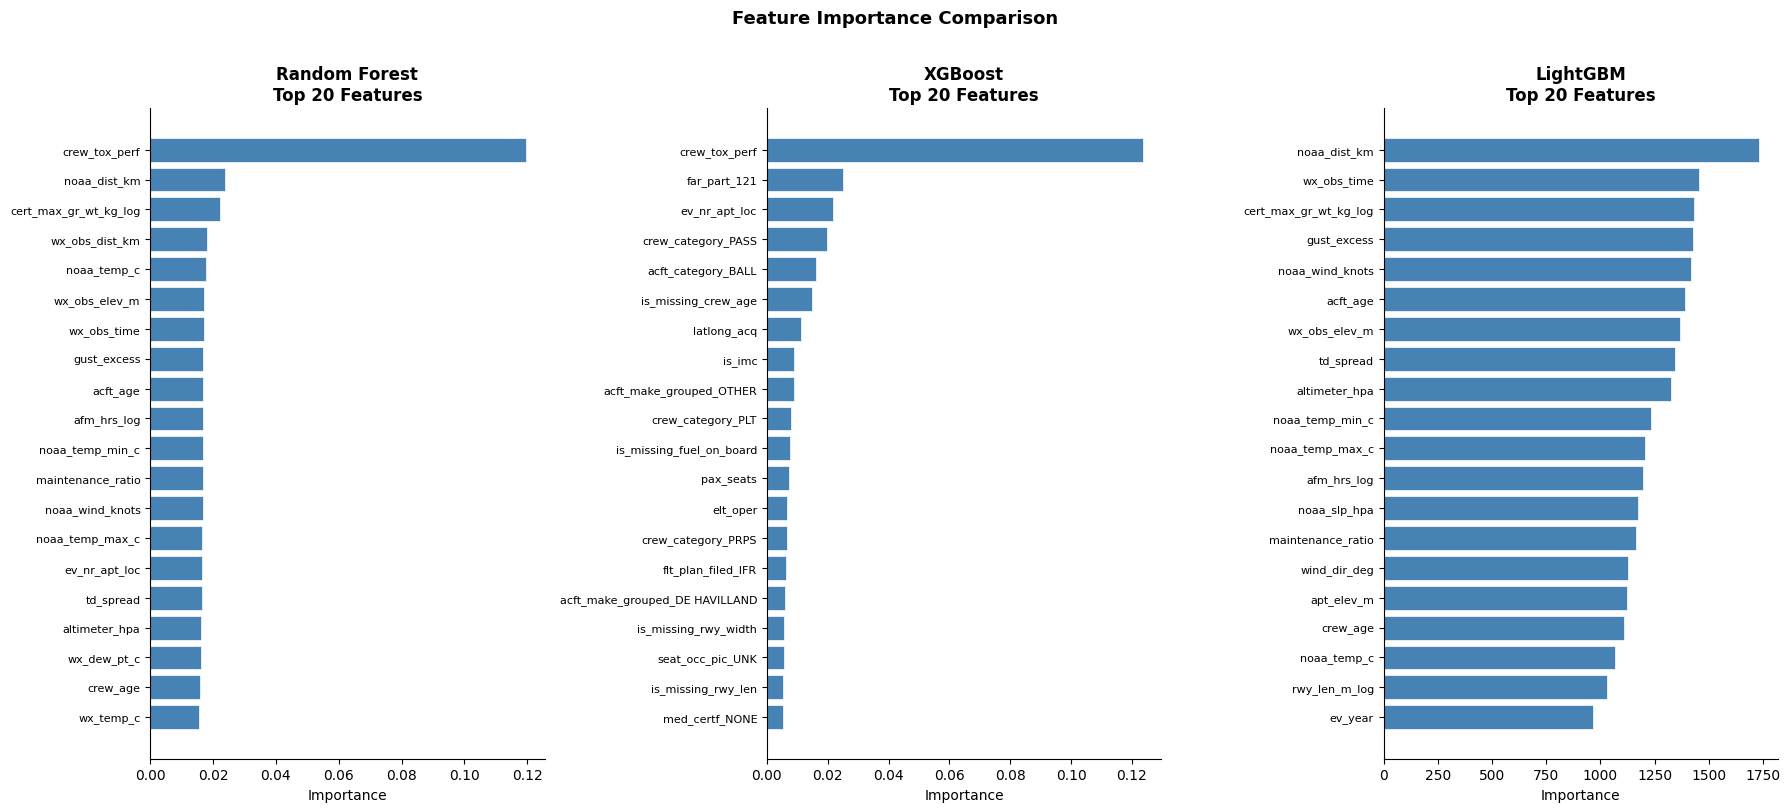

In [28]:
try:
    feature_names = pd.read_csv(f'{OUTPUT_DIR}/feature_names.csv').squeeze().tolist()
except:
    feature_names = [f'f{i}' for i in range(X_train.shape[1])]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
tree_models_fi = [
    (rf,        'Random Forest',  'feature_importances_'),
    (xgb_model, 'XGBoost',        'feature_importances_'),
    (lgb_model, 'LightGBM',       'feature_importances_'),
]
for ax, (model, name, attr) in zip(axes, tree_models_fi):
    imps = getattr(model, attr)
    top_idx   = np.argsort(imps)[-20:][::-1]
    top_names = [feature_names[i] if i < len(feature_names) else f'f{i}' for i in top_idx]
    top_vals  = imps[top_idx]
    ax.barh(range(20), top_vals[::-1], color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(20)); ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_title(f'{name}\nTop 20 Features', fontweight='bold')
    ax.set_xlabel('Importance')
    sns.despine(ax=ax)

plt.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/feature_importance_top20.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
print(f'  Models trained       : 6')
print(f'  CV folds             : {N_CV_FOLDS}-fold stratified')
print(f'  Best model (val)     : {best_model_name}')
print(f'  Best val FATL recall : {results_df.iloc[0]["fatl_recall"]:.4f}')
print(f'  Test macro F1        : {metrics_test["macro_f1"]:.4f}')
print(f'  Test FATL recall     : {metrics_test["fatl_recall"]:.4f}')
print()


  Models trained       : 6
  CV folds             : 5-fold stratified
  Best model (val)     : LightGBM
  Best val FATL recall : 0.8773
  Test macro F1        : 0.6436
  Test FATL recall     : 0.8877



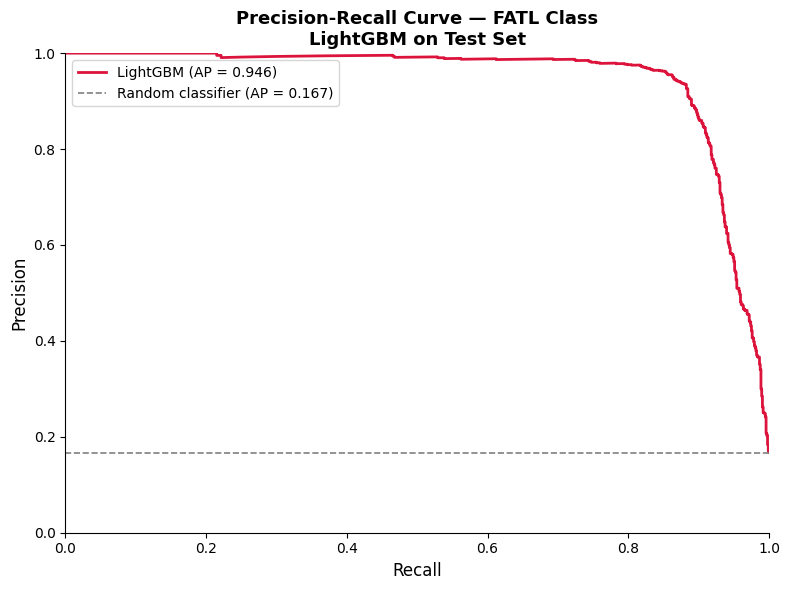

Average Precision (FATL): 0.9459
Baseline (random):        0.1670
Improvement over random:  5.67x


In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities for FATL class (index 3)
y_prob_test = best_model.predict_proba(X_test_for_best)
y_prob_fatl = y_prob_test[:, 3]

# Binary: is the true class FATL or not
y_true_fatl = (y_test.values == 3).astype(int)

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_true_fatl, y_prob_fatl)
ap = average_precision_score(y_true_fatl, y_prob_fatl)

# Baseline (random classifier) = proportion of FATL in test set
baseline = y_true_fatl.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='crimson', linewidth=2,
        label=f'{best_model_name} (AP = {ap:.3f})')
ax.axhline(baseline, color='gray', linewidth=1.2, linestyle='--',
           label=f'Random classifier (AP = {baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision-Recall Curve — FATL Class\n{best_model_name} on Test Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/pr_curve_fatl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average Precision (FATL): {ap:.4f}')
print(f'Baseline (random):        {baseline:.4f}')
print(f'Improvement over random:  {ap/baseline:.2f}x')